# Лабораторная — Часть 1: Датасет
## Chess Pieces Detection

**Практическая задача:** Автоматическое распознавание шахматных фигур на доске по изображению с камеры. Применяется в системах компьютерного анализа партий, обучающих программах и робототехнике.

**Метрики качества:**
| Метрика | Обоснование |
|---|---|
| mAP@50 | Основная метрика детекции, IoU≥0.5 достаточно для задачи |
| mAP@50-95 | Строгая оценка локализации (стандарт COCO) |
| Precision | Минимизация ложных детекций фигур |
| Recall | Минимизация пропущенных фигур |
| Inference time | Важна скорость для real-time анализа |

In [1]:
import os, yaml
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Patch
from PIL import Image as PILImage

%matplotlib inline

DATASET_DIR = Path('')
DATA_YAML   = DATASET_DIR / 'data.yaml'

assert DATASET_DIR.exists(), f'Не найдена папка: {DATASET_DIR.absolute()}'
assert DATA_YAML.exists(),   f'Не найден: {DATA_YAML.absolute()}'

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

CLASS_NAMES = cfg['names']
NUM_CLASSES = cfg['nc']
print(f'Классов: {NUM_CLASSES}')
print(f'Классы:  {CLASS_NAMES}')
print()
print('data.yaml:')
print(open(DATA_YAML).read())

Классов: 13
Классы:  {0: 'bishop', 1: 'black-bishop', 2: 'black-king', 3: 'black-knight', 4: 'black-pawn', 5: 'black-queen', 6: 'black-rook', 7: 'white-bishop', 8: 'white-king', 9: 'white-knight', 10: 'white-pawn', 11: 'white-queen', 12: 'white-rook'}

data.yaml:
names:
  0: bishop
  1: black-bishop
  2: black-king
  3: black-knight
  4: black-pawn
  5: black-queen
  6: black-rook
  7: white-bishop
  8: white-king
  9: white-knight
  10: white-pawn
  11: white-queen
  12: white-rook
nc: 13
path: C:\Users\meteo\Desktop\cyber-physical-systems\lr11
test: test/images
train: train/images
val: valid/images



In [2]:
new_cfg = {
    'path':  str(DATASET_DIR.absolute()),
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc':    NUM_CLASSES,
    'names': CLASS_NAMES,
}
with open(DATA_YAML, 'w') as f:
    yaml.dump(new_cfg, f, allow_unicode=True, default_flow_style=False)

print('data.yaml обновлён:')
print(open(DATA_YAML).read())

data.yaml обновлён:
names:
  0: bishop
  1: black-bishop
  2: black-king
  3: black-knight
  4: black-pawn
  5: black-queen
  6: black-rook
  7: white-bishop
  8: white-king
  9: white-knight
  10: white-pawn
  11: white-queen
  12: white-rook
nc: 13
path: C:\Users\meteo\Desktop\cyber-physical-systems\lr11
test: test/images
train: train/images
val: valid/images



In [3]:
def count_split(split):
    cnt, bpi = Counter(), []
    lbl_dir = DATASET_DIR / split / 'labels'
    if not lbl_dir.exists(): return cnt, bpi
    for f in lbl_dir.glob('*.txt'):
        lines = [l for l in f.read_text().splitlines() if l.strip()]
        bpi.append(len(lines))
        for l in lines:
            cid = int(l.split()[0])
            if cid < len(CLASS_NAMES): cnt[CLASS_NAMES[cid]] += 1
    return cnt, bpi

tr_cnt, tr_bpi = count_split('train')
va_cnt, va_bpi = count_split('valid')
te_cnt, te_bpi = count_split('test')

n_tr = len(list((DATASET_DIR/'train'/'images').iterdir()))
n_va = len(list((DATASET_DIR/'valid'/'images').iterdir()))
n_te = len(list((DATASET_DIR/'test' /'images').iterdir()))

print(f"{'Класс':<22} {'Train':>8} {'Val':>8} {'Test':>8}")
print('-'*48)
for c in CLASS_NAMES:
    
    print(f"{c:<22} {tr_cnt.get(CLASS_NAMES[c],0):>8} {va_cnt.get(CLASS_NAMES[c],0):>8} {te_cnt.get(CLASS_NAMES[c],0):>8}")
print('-'*48)
print(f"{'ИТОГО объектов':<22} {sum(tr_cnt.values()):>8} {sum(va_cnt.values()):>8} {sum(te_cnt.values()):>8}")
print(f"{'Изображений':<22} {n_tr:>8} {n_va:>8} {n_te:>8}")

Класс                     Train      Val     Test
------------------------------------------------
0                             3        0        0
1                           291       22       21
2                           303       29       17
3                           423       30       25
4                          1488       77       86
5                           186       11       14
6                           441       28       26
7                           375       22       25
8                           315       29       15
9                           420       19       25
10                         1422       77       88
11                          243       16       14
12                          414       26       20
------------------------------------------------
ИТОГО объектов             6324      386      376
Изображений                 606       58       29


['bishop', 'black-bishop', 'black-king', 'black-knight', 'black-pawn', 'black-queen', 'black-rook', 'white-bishop', 'white-king', 'white-knight', 'white-pawn', 'white-queen', 'white-rook']


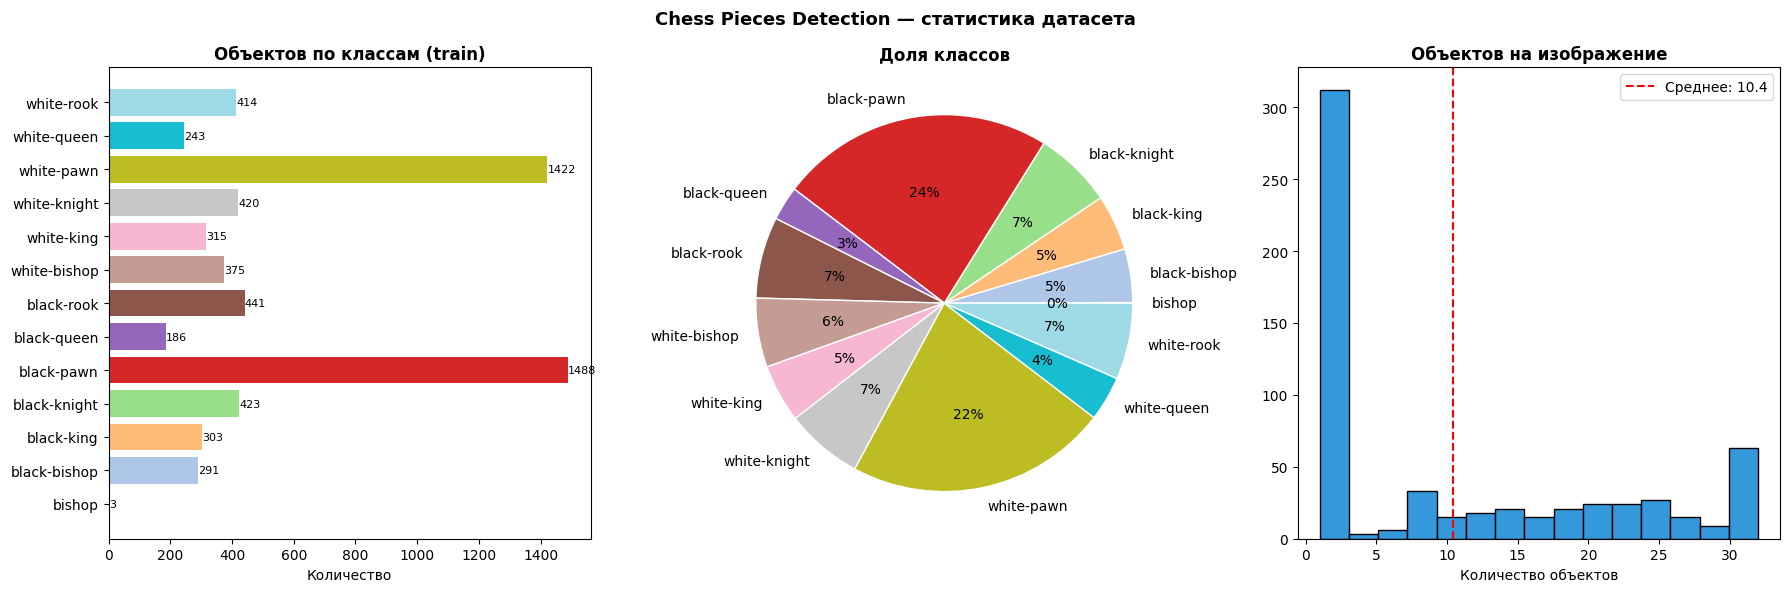

In [8]:
from IPython.display import display
if isinstance(CLASS_NAMES, dict):
    CLASS_NAMES = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]
cmap = plt.cm.tab20(np.linspace(0, 1, max(len(CLASS_NAMES), 1)))
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Chess Pieces Detection — статистика датасета', fontsize=13, fontweight='bold')

# Исправлено: c это уже строка, не индекс
vals = [tr_cnt.get(c, 0) for c in CLASS_NAMES]

# График 1: горизонтальные бары
axes[0].barh(CLASS_NAMES, vals, color=cmap)
axes[0].set_title('Объектов по классам (train)', fontweight='bold')
axes[0].set_xlabel('Количество')
for i, v in enumerate(vals):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=8)

# График 2: pie только ненулевые
nz = [(c, v) for c, v in zip(CLASS_NAMES, vals) if v > 0]
if nz:
    lb, vl = zip(*nz)
    axes[1].pie(vl, labels=lb, autopct='%1.0f%%',
                colors=cmap[:len(vl)],
                wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[1].set_title('Доля классов', fontweight='bold')

# График 3: гистограмма
if tr_bpi:
    axes[2].hist(tr_bpi, bins=15, color='#3498DB', edgecolor='black')
    axes[2].axvline(np.mean(tr_bpi), color='red', linestyle='--',
                    label=f'Среднее: {np.mean(tr_bpi):.1f}')
    axes[2].set_title('Объектов на изображение', fontweight='bold')
    axes[2].set_xlabel('Количество объектов')
    axes[2].legend()

plt.tight_layout()
display(fig)
plt.close()

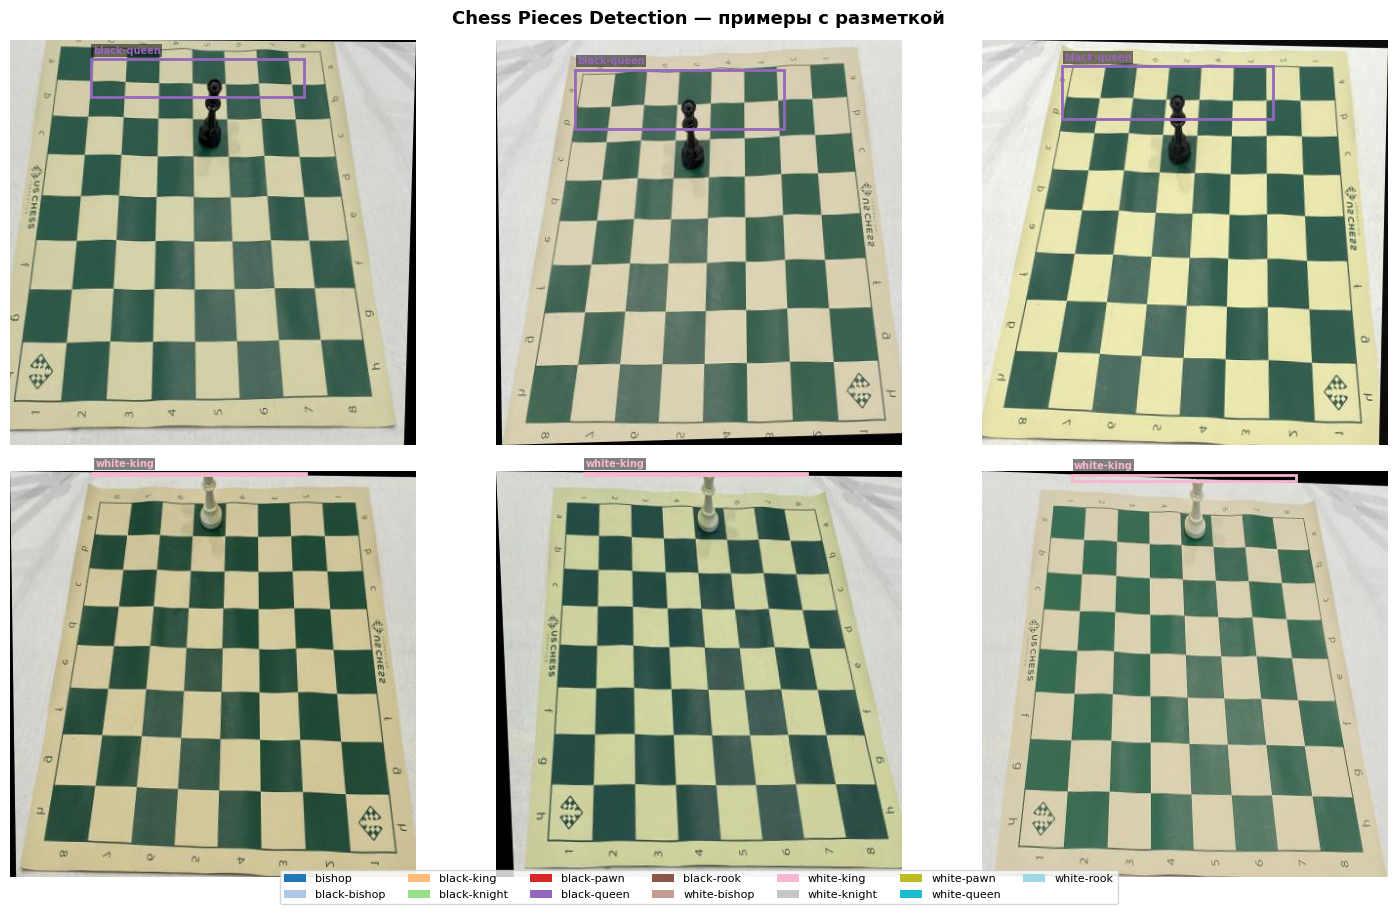

In [5]:
img_dir  = DATASET_DIR / 'train' / 'images'
lbl_dir  = DATASET_DIR / 'train' / 'labels'
img_files = sorted(img_dir.iterdir())[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
fig.suptitle('Chess Pieces Detection — примеры с разметкой', fontsize=13, fontweight='bold')

for ax, img_path in zip(axes, img_files):
    img = PILImage.open(img_path).convert('RGB')
    W, H = img.size
    ax.imshow(img); ax.axis('off')
    lbl = lbl_dir / (img_path.stem + '.txt')
    if lbl.exists():
        for line in lbl.read_text().splitlines():
            if not line.strip(): continue
            p = line.split()
            cid = int(p[0])
            cx, cy, bw, bh = map(float, p[1:5])
            x1 = (cx-bw/2)*W; y1 = (cy-bh/2)*H
            color = cmap[cid % len(cmap)]
            ax.add_patch(patches.Rectangle((x1,y1),bw*W,bh*H,
                         linewidth=2,edgecolor=color,facecolor='none'))
            if cid < len(CLASS_NAMES):
                ax.text(x1+2,y1-6,CLASS_NAMES[cid],color=color,fontsize=7,fontweight='bold',
                        bbox=dict(facecolor='black',alpha=0.5,pad=1,edgecolor='none'))

fig.legend(handles=[Patch(facecolor=cmap[i],label=CLASS_NAMES[i]) for i in range(len(CLASS_NAMES))],
           loc='lower center', ncol=min(len(CLASS_NAMES),7),
           fontsize=8, bbox_to_anchor=(0.5,-0.02))
plt.tight_layout()
plt.show()
